<a href="https://colab.research.google.com/github/silvjunu/devowel/blob/main/devowel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DeVowel: Exploring Vowel-Reduced Vocal Timbre

This notebook investigates vowel-dependent spectral structure in sustained voice recordings.

Current analysis stages:

1. load and inspect recordings,
2. check recording quality and pitch consistency,
3. compute FFT magnitude spectra,
4. estimate Gaussian-smoothed spectral envelopes,
5. test within-vowel repeatability,
6. detect exploratory resonance candidates,
7. compare Gaussian and LPC spectral envelopes,
8. examine LPC-order stability,
9. estimate LPC pole frequencies and bandwidths.

The long-term goal is to identify and manipulate vowel-dependent vocal-tract structure while preserving as much speaker-dependent vocal character as possible.

In [44]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Environment and Project Paths

The original recordings are stored in Google Drive.

Directory structure:

- `audio/raw`: original M4A recordings
- `audio/wav`: WAV files used for analysis

The Colab runtime itself is temporary, so persistent audio data is kept in Google Drive.

In [45]:
import shutil
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import soundfile as sf
import librosa

from pathlib import Path
from IPython.display import Audio, display

from scipy.ndimage import gaussian_filter1d
from scipy.signal import (
  correlate,
  find_peaks,
  resample_poly,
  freqz,
  lfilter,
)


project_dir = Path(
  "/content/drive/MyDrive/devowel"
)

audio_dir = (
  project_dir / "audio"
)

raw_dir = (
  audio_dir / "raw"
)

wav_dir = (
  audio_dir / "wav"
)


wav_dir.mkdir(
  parents=True,
  exist_ok=True,
)


m4a_files = sorted(
  raw_dir.glob("*.m4a")
)

wav_files = sorted(
  wav_dir.glob("*.wav")
)


print("Environment ready.")
print("Project folder:", project_dir)
print("Raw folder:", raw_dir)
print("WAV folder:", wav_dir)

print()
print("M4A files:", len(m4a_files))
print("WAV files:", len(wav_files))

Environment ready.
Project folder: /content/drive/MyDrive/devowel
Raw folder: /content/drive/MyDrive/devowel/audio/raw
WAV folder: /content/drive/MyDrive/devowel/audio/wav

M4A files: 10
WAV files: 10


## 2. Audio Conversion

The original phone recordings are stored as M4A files.

For analysis they are converted to:

- mono,
- 44.1 kHz,
- WAV.

Existing WAV files can be reused.

In [46]:
if shutil.which("ffmpeg") is None:
  raise RuntimeError(
    "FFmpeg is not available."
  )


for input_path in m4a_files:
  output_path = (
    wav_dir
    / f"{input_path.stem}.wav"
  )

  if output_path.exists():
    print(
      f"Already exists: {output_path.name}"
    )
    continue


  command = [
    "ffmpeg",
    "-y",
    "-i", str(input_path),
    "-ac", "1",
    "-ar", "44100",
    str(output_path),
  ]


  subprocess.run(
    command,
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL,
    check=True,
  )


  print(
    f"{input_path.name}"
    f" -> "
    f"{output_path.name}"
  )


wav_files = sorted(
  wav_dir.glob("*.wav")
)


print()
print(
  "WAV files ready:",
  len(wav_files),
)

Already exists: a_01.wav
Already exists: a_02.wav
Already exists: e_01.wav
Already exists: e_02.wav
Already exists: i_01.wav
Already exists: i_02.wav
Already exists: o_01.wav
Already exists: o_02.wav
Already exists: u_01.wav
Already exists: u_02.wav

WAV files ready: 10


## 3. Basic Audio Inspection

Before spectral analysis, one recording is inspected directly.

The inspection includes:

- sample rate,
- duration,
- peak amplitude,
- RMS level,
- clipping,
- waveform,
- audio playback.

In [47]:
def inspect_audio(audio_path):
  wave, sr = sf.read(
    audio_path
  )


  duration = (
    len(wave) / sr
  )


  peak_amp = np.max(
    np.abs(wave)
  )


  rms = np.sqrt(
    np.mean(
      wave ** 2
    )
  )


  clip_count = np.sum(
    np.abs(wave) >= 0.999
  )


  print(
    "File:",
    audio_path.name,
  )

  print(
    "Sample rate:",
    sr,
    "Hz",
  )

  print(
    "Shape:",
    wave.shape,
  )

  print(
    f"Duration: {duration:.2f} s"
  )

  print(
    f"Peak amplitude: {peak_amp:.4f}"
  )

  print(
    f"RMS: {rms:.4f}"
  )

  print(
    "Samples near clipping:",
    clip_count,
  )


  display(
    Audio(
      wave,
      rate=sr,
    )
  )


  time = (
    np.arange(
      len(wave)
    )
    / sr
  )


  plt.figure(
    figsize=(12, 4)
  )

  plt.plot(
    time,
    wave,
  )

  plt.xlabel(
    "Time (s)"
  )

  plt.ylabel(
    "Amplitude"
  )

  plt.title(
    f"Waveform — {audio_path.stem}"
  )

  plt.show()


  return wave, sr

File: a_01.wav
Sample rate: 44100 Hz
Shape: (238023,)
Duration: 5.40 s
Peak amplitude: 0.7024
RMS: 0.0912
Samples near clipping: 0


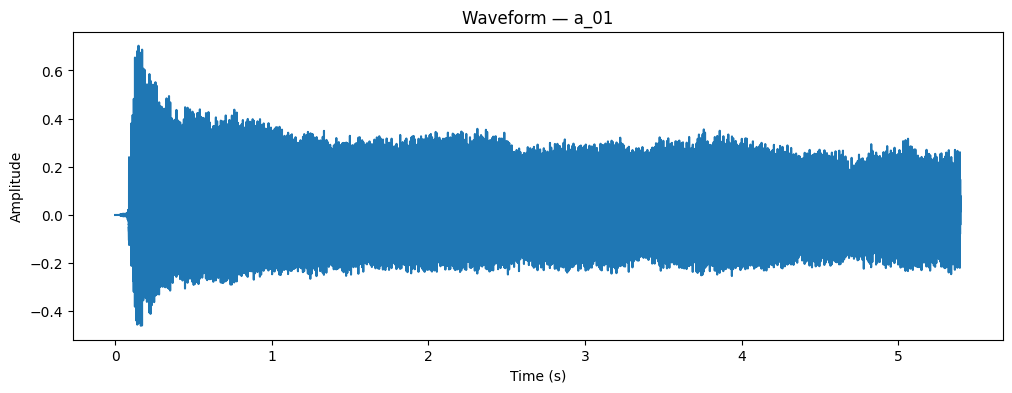

In [48]:
audio_path = (
  wav_dir / "a_01.wav"
)

wave, sr = inspect_audio(
  audio_path
)

## 4. Dataset Quality Check

All recordings are checked for basic technical consistency.

The measurements include:

- duration,
- peak amplitude,
- RMS,
- clipping count.

This is a technical quality-control step rather than an acoustic model of vowel identity.

In [49]:
qc_rows = []


for audio_path in wav_files:
  wave_temp, sr_temp = sf.read(
    audio_path
  )


  duration = (
    len(wave_temp)
    / sr_temp
  )


  peak_amp = np.max(
    np.abs(wave_temp)
  )


  rms = np.sqrt(
    np.mean(
      wave_temp ** 2
    )
  )


  clip_count = np.sum(
    np.abs(wave_temp) >= 0.999
  )


  qc_rows.append({
    "file": audio_path.name,
    "duration_s": duration,
    "peak_amp": peak_amp,
    "rms": rms,
    "clip_count": clip_count,
  })


qc_df = pd.DataFrame(
  qc_rows
)


qc_df = qc_df.round({
  "duration_s": 2,
  "peak_amp": 4,
  "rms": 4,
})


display(
  qc_df
)

,file,duration_s,peak_amp,rms,clip_count
0,a_01.wav,5.40,0.7024,0.0912,0
1,a_02.wav,6.25,0.4359,0.0776,0
2,e_01.wav,6.23,0.3087,0.0673,0
3,e_02.wav,5.44,0.2625,0.0560,0
4,i_01.wav,5.40,0.1791,0.0659,0
5,i_02.wav,6.08,0.1623,0.0532,0
6,o_01.wav,6.17,0.2318,0.0579,0
7,o_02.wav,5.50,0.1819,0.0476,0
8,u_01.wav,6.57,0.2397,0.0675,0
9,u_02.wav,6.21,0.1647,0.0480,0


## 5. Fundamental-Frequency Check

The recordings should have reasonably similar fundamental frequencies because vowel spectra are sampled by harmonics whose spacing depends on f0.

A simple autocorrelation-based estimator is used to check pitch consistency.

This f0 estimator is used for quality control rather than as the central DeVowel algorithm.

In [50]:
def estimate_frame_f0(
  frame,
  sr,
  fmin=70,
  fmax=500,
):
  frame = (
    frame
    - np.mean(frame)
  )


  frame = (
    frame
    * np.hanning(
      len(frame)
    )
  )


  autocorr = correlate(
    frame,
    frame,
    mode="full",
    method="fft",
  )


  autocorr = autocorr[
    len(autocorr) // 2:
  ]


  min_lag = int(
    sr / fmax
  )

  max_lag = int(
    sr / fmin
  )


  search = autocorr[
    min_lag:
    max_lag + 1
  ]


  peak_lag = (
    np.argmax(search)
    + min_lag
  )


  return (
    sr / peak_lag
  )

In [51]:
def estimate_audio_f0(
  wave,
  sr,
  center_duration=2.0,
):
  center_sample = (
    len(wave) // 2
  )


  half_length = int(
    center_duration
    * sr
    / 2
  )


  start = max(
    0,
    center_sample - half_length,
  )

  end = min(
    len(wave),
    center_sample + half_length,
  )


  stable_wave = wave[
    start:end
  ]


  frame_length = int(
    0.05 * sr
  )

  hop_length = int(
    0.02 * sr
  )


  f0_values = []


  for start_idx in range(
    0,
    len(stable_wave)
    - frame_length,
    hop_length,
  ):
    frame = stable_wave[
      start_idx:
      start_idx + frame_length
    ]


    frame_rms = np.sqrt(
      np.mean(
        frame ** 2
      )
    )


    if frame_rms < 0.01:
      continue


    f0 = estimate_frame_f0(
      frame,
      sr,
    )


    f0_values.append(
      f0
    )


  return np.array(
    f0_values
  )

In [52]:
def estimate_audio_f0(
  wave,
  sr,
  center_duration=2.0,
):
  center_sample = (
    len(wave) // 2
  )


  half_length = int(
    center_duration
    * sr
    / 2
  )


  start = max(
    0,
    center_sample - half_length,
  )

  end = min(
    len(wave),
    center_sample + half_length,
  )


  stable_wave = wave[
    start:end
  ]


  frame_length = int(
    0.05 * sr
  )

  hop_length = int(
    0.02 * sr
  )


  f0_values = []


  for start_idx in range(
    0,
    len(stable_wave)
    - frame_length,
    hop_length,
  ):
    frame = stable_wave[
      start_idx:
      start_idx + frame_length
    ]


    frame_rms = np.sqrt(
      np.mean(
        frame ** 2
      )
    )


    if frame_rms < 0.01:
      continue


    f0 = estimate_frame_f0(
      frame,
      sr,
    )


    f0_values.append(
      f0
    )


  return np.array(
    f0_values
  )

## 6. Spectrum Analysis

For each recording, the stable central 2 seconds are analyzed.

Pipeline:

1. select the central segment,
2. remove DC offset,
3. apply a Hann window,
4. compute the real FFT,
5. calculate magnitude,
6. create the frequency axis,
7. convert magnitude to dB,
8. normalize the maximum to 0 dB.

The narrow peaks of the raw spectrum mainly correspond to source harmonics.

The broader shape across harmonics is related to vocal-tract filtering.

In [53]:
def compute_spectrum(
  wave,
  sr,
  center_duration=2.0,
):
  center_sample = (
    len(wave) // 2
  )


  half_length = int(
    center_duration
    * sr
    / 2
  )


  start = max(
    0,
    center_sample - half_length,
  )

  end = min(
    len(wave),
    center_sample + half_length,
  )


  stable_wave = wave[
    start:end
  ]


  stable_wave = (
    stable_wave
    - np.mean(stable_wave)
  )


  window = np.hanning(
    len(stable_wave)
  )


  windowed_wave = (
    stable_wave
    * window
  )


  spectrum = np.fft.rfft(
    windowed_wave
  )


  mag = np.abs(
    spectrum
  )


  freqs = np.fft.rfftfreq(
    len(windowed_wave),
    d=1 / sr,
  )


  mag_db = (
    20
    * np.log10(
      mag + 1e-12
    )
  )


  mag_db = (
    mag_db
    - np.max(mag_db)
  )


  return (
    freqs,
    mag_db,
  )

In [54]:
audio_path = (
  wav_dir / "a_01.wav"
)

wave, sr = sf.read(
  audio_path
)


freqs, mag_db = compute_spectrum(
  wave,
  sr,
)


print(
  "Sample rate:",
  sr,
)

print(
  "Frequency bins:",
  len(freqs),
)

print(
  "Spectrum bins:",
  len(mag_db),
)

print(
  "First frequencies:",
  freqs[:5],
)

print(
  "Last frequency:",
  freqs[-1],
)

print(
  "Bin spacing:",
  freqs[1] - freqs[0],
  "Hz",
)

print(
  "Maximum magnitude:",
  np.max(mag_db),
)

Sample rate: 44100
Frequency bins: 44101
Spectrum bins: 44101
First frequencies: [0.  0.5 1.  1.5 2. ]
Last frequency: 22050.0
Bin spacing: 0.5 Hz
Maximum magnitude: 0.0


### 6.1 Raw Spectrum

The raw FFT spectrum contains many narrow harmonic peaks.

These individual peaks should not be interpreted directly as formants.

Formants are broader vocal-tract resonances that shape the relative amplitudes of multiple harmonics.

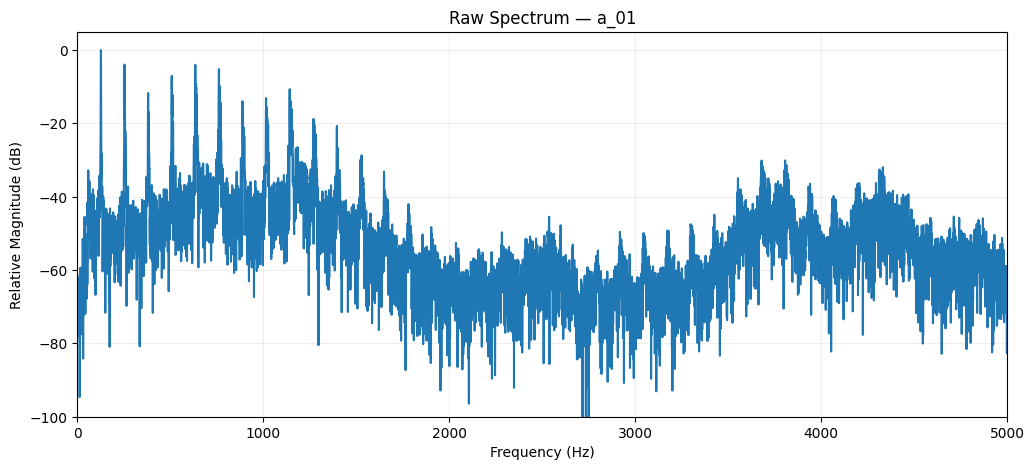

In [55]:
mask = (
  freqs <= 5000
)


plt.figure(
  figsize=(12, 5)
)


plt.plot(
  freqs[mask],
  mag_db[mask],
)


plt.xlabel(
  "Frequency (Hz)"
)

plt.ylabel(
  "Relative Magnitude (dB)"
)

plt.title(
  "Raw Spectrum — a_01"
)

plt.xlim(
  0,
  5000,
)

plt.ylim(
  -100,
  5,
)

plt.grid(
  alpha=0.2
)


plt.show()

## 7. Gaussian-Smoothed Spectral Envelope

The raw spectrum is dominated by narrow harmonic peaks.

Gaussian smoothing is used as a first exploratory approximation of the broader spectral envelope.

The smoothing parameter is specified in Hz but `gaussian_filter1d()` operates in array-bin units.

Therefore:

smoothing width in Hz
→ divide by FFT-bin spacing
→ smoothing sigma in bins

After smoothing, the envelope is normalized again so that its maximum is 0 dB.

This curve is an exploratory spectral-envelope estimate, not a formal formant measurement.

In [56]:
def compute_spectral_envelope(
  freqs,
  mag_db,
  smoothing_sigma_hz=50,
):
  bin_spacing_hz = (
    freqs[1]
    - freqs[0]
  )


  sigma_bins = (
    smoothing_sigma_hz
    / bin_spacing_hz
  )


  envelope_db = gaussian_filter1d(
    mag_db,
    sigma=sigma_bins,
  )


  envelope_db = (
    envelope_db
    - np.max(envelope_db)
  )


  return envelope_db

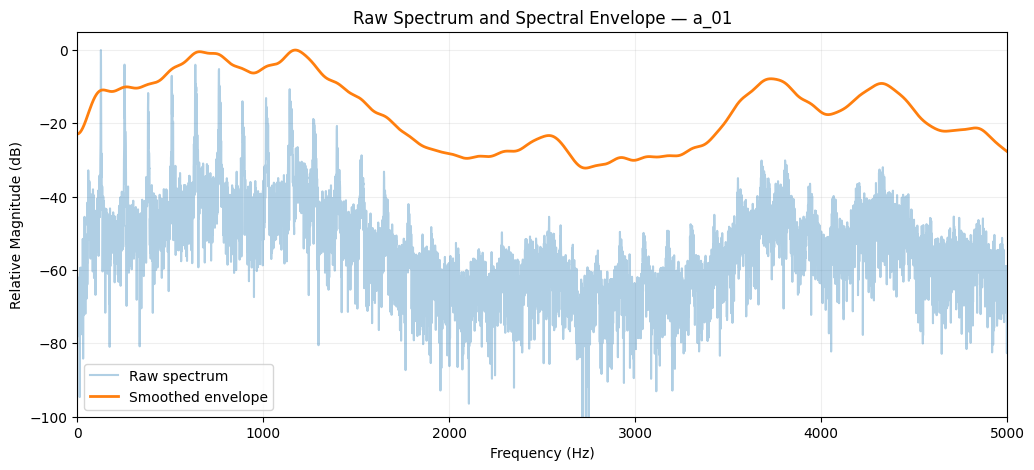

In [57]:
envelope_db = compute_spectral_envelope(
  freqs,
  mag_db,
  smoothing_sigma_hz=50,
)


mask = (
  freqs <= 5000
)


plt.figure(
  figsize=(12, 5)
)


plt.plot(
  freqs[mask],
  mag_db[mask],
  alpha=0.35,
  label="Raw spectrum",
)


plt.plot(
  freqs[mask],
  envelope_db[mask],
  linewidth=2,
  label="Smoothed envelope",
)


plt.xlabel(
  "Frequency (Hz)"
)

plt.ylabel(
  "Relative Magnitude (dB)"
)

plt.title(
  "Raw Spectrum and Spectral Envelope — a_01"
)

plt.xlim(
  0,
  5000,
)

plt.ylim(
  -100,
  5,
)

plt.legend()

plt.grid(
  alpha=0.2
)


plt.show()

## 8. Vowel Spectral-Envelope Comparison

One take from each vowel is compared.

Each envelope is normalized independently.

The purpose is therefore to compare broad spectral shape rather than absolute recording loudness.

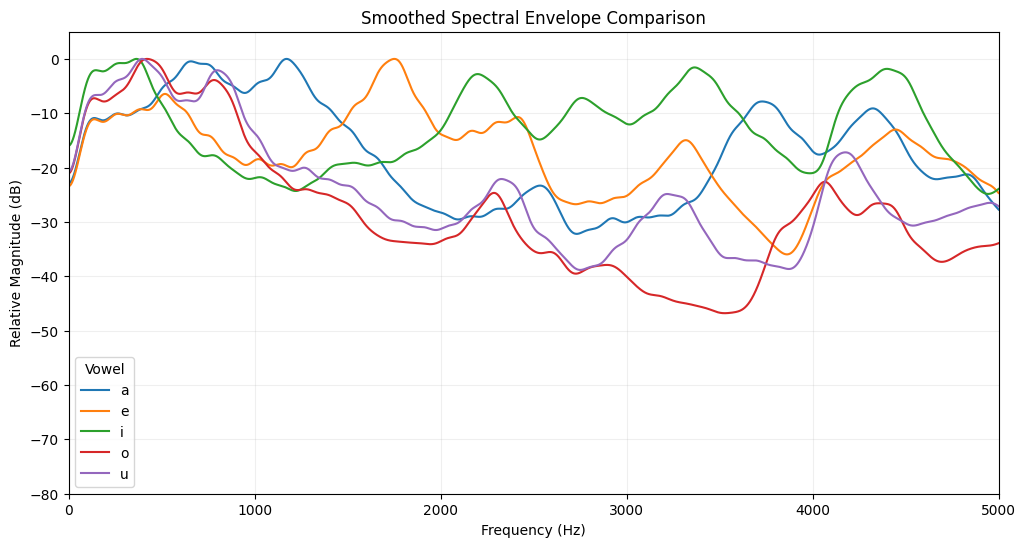

In [58]:
vowels = [
  "a",
  "e",
  "i",
  "o",
  "u",
]


comparison_files = [
  "a_01.wav",
  "e_01.wav",
  "i_01.wav",
  "o_01.wav",
  "u_01.wav",
]


plt.figure(
  figsize=(12, 6)
)


for filename in comparison_files:
  audio_path = (
    wav_dir / filename
  )


  wave_temp, sr_temp = sf.read(
    audio_path
  )


  freqs_temp, mag_db_temp = compute_spectrum(
    wave_temp,
    sr_temp,
  )


  envelope_temp = compute_spectral_envelope(
    freqs_temp,
    mag_db_temp,
    smoothing_sigma_hz=50,
  )


  mask = (
    freqs_temp <= 5000
  )


  plt.plot(
    freqs_temp[mask],
    envelope_temp[mask],
    label=filename[0],
  )


plt.xlabel(
  "Frequency (Hz)"
)

plt.ylabel(
  "Relative Magnitude (dB)"
)

plt.title(
  "Smoothed Spectral Envelope Comparison"
)

plt.xlim(
  0,
  5000,
)

plt.ylim(
  -80,
  5,
)

plt.legend(
  title="Vowel"
)

plt.grid(
  alpha=0.2
)


plt.show()

## 9. Within-Vowel Repeatability

Each vowel was recorded twice.

The two takes of each vowel are compared to determine whether the broad spectral-envelope structure is repeatable.

Stable similarity within vowels is necessary before interpreting differences between vowels as vowel-dependent structure.

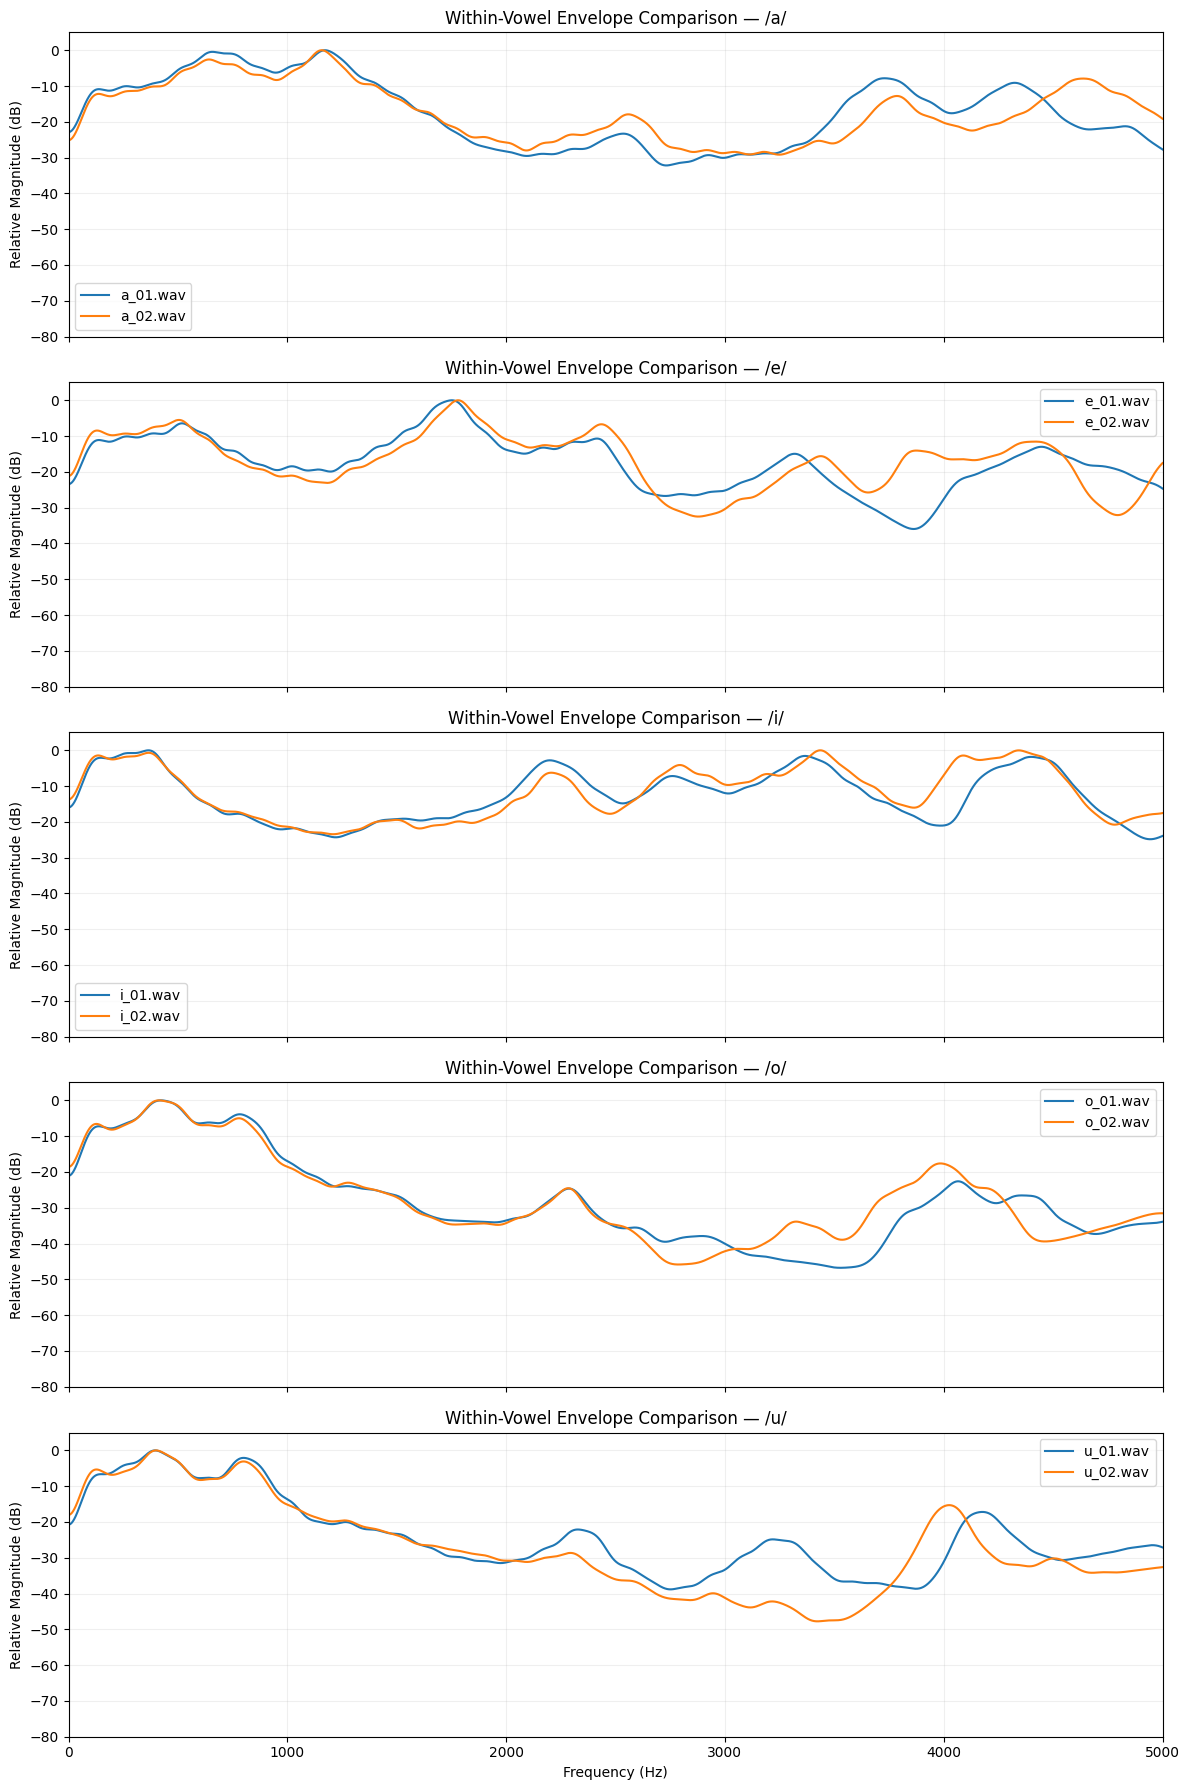

In [59]:
fig, axes = plt.subplots(
  len(vowels),
  1,
  figsize=(12, 18),
  sharex=True,
  sharey=True,
)


for ax, vowel in zip(
  axes,
  vowels,
):
  filenames = [
    f"{vowel}_01.wav",
    f"{vowel}_02.wav",
  ]


  for filename in filenames:
    audio_path = (
      wav_dir / filename
    )


    wave_temp, sr_temp = sf.read(
      audio_path
    )


    freqs_temp, mag_db_temp = compute_spectrum(
      wave_temp,
      sr_temp,
    )


    envelope_temp = compute_spectral_envelope(
      freqs_temp,
      mag_db_temp,
      smoothing_sigma_hz=50,
    )


    mask = (
      freqs_temp <= 5000
    )


    ax.plot(
      freqs_temp[mask],
      envelope_temp[mask],
      label=filename,
    )


  ax.set_title(
    f"Within-Vowel Envelope Comparison — /{vowel}/"
  )

  ax.set_ylabel(
    "Relative Magnitude (dB)"
  )

  ax.set_ylim(
    -80,
    5,
  )

  ax.grid(
    alpha=0.2
  )

  ax.legend()


axes[-1].set_xlabel(
  "Frequency (Hz)"
)

axes[-1].set_xlim(
  0,
  5000,
)


plt.tight_layout()

plt.show()

In [60]:
envelopes = {}

reference_freqs = None


for audio_path in wav_files:
  wave_temp, sr_temp = sf.read(
    audio_path
  )


  freqs_temp, mag_db_temp = compute_spectrum(
    wave_temp,
    sr_temp,
  )


  envelope_temp = compute_spectral_envelope(
    freqs_temp,
    mag_db_temp,
    smoothing_sigma_hz=50,
  )


  if reference_freqs is None:
    reference_freqs = (
      freqs_temp
    )


  if not np.allclose(
    freqs_temp,
    reference_freqs,
  ):
    raise ValueError(
      "Frequency axes are not identical."
    )


  envelopes[
    audio_path.name
  ] = envelope_temp


print(
  "Stored envelopes:",
  len(envelopes),
)

Stored envelopes: 10


### 9.1 Numerical Envelope Similarity

Two exploratory similarity measurements are used:

- Pearson correlation: similarity of overall curve shape.
- MAE (Mean Absolute Error): average absolute difference in dB.

Higher correlation and lower MAE indicate greater similarity.

These are exploratory descriptors rather than definitive perceptual-distance measures.

In [61]:
analysis_mask = (
  (reference_freqs >= 100)
  & (reference_freqs <= 5000)
)


repeatability_rows = []


for vowel in vowels:
  file_01 = (
    f"{vowel}_01.wav"
  )

  file_02 = (
    f"{vowel}_02.wav"
  )


  envelope_01 = envelopes[
    file_01
  ][analysis_mask]


  envelope_02 = envelopes[
    file_02
  ][analysis_mask]


  corr = np.corrcoef(
    envelope_01,
    envelope_02,
  )[0, 1]


  mae_db = np.mean(
    np.abs(
      envelope_01
      - envelope_02
    )
  )


  repeatability_rows.append({
    "vowel": vowel,
    "correlation": corr,
    "mae_db": mae_db,
  })


repeatability_df = pd.DataFrame(
  repeatability_rows
)


repeatability_df = repeatability_df.round({
  "correlation": 3,
  "mae_db": 2,
})


display(
  repeatability_df
)

,vowel,correlation,mae_db
0,a,0.850,3.77
1,e,0.709,4.21
2,i,0.874,2.45
3,o,0.923,3.19
4,u,0.870,4.84


### 9.2 Within-Vowel vs Between-Vowel Differences

All recording pairs are classified as:

- `within`: two takes of the same vowel,
- `between`: recordings of different vowels.

If within-vowel pairs are systematically more similar than between-vowel pairs, the envelope representation contains stable vowel-dependent information.

In [62]:
pair_rows = []


filenames = sorted(
  envelopes.keys()
)


for i in range(
  len(filenames)
):
  for j in range(
    i + 1,
    len(filenames)
  ):
    file_a = filenames[i]
    file_b = filenames[j]


    vowel_a = file_a[0]
    vowel_b = file_b[0]


    envelope_a = envelopes[
      file_a
    ][analysis_mask]


    envelope_b = envelopes[
      file_b
    ][analysis_mask]


    corr = np.corrcoef(
      envelope_a,
      envelope_b,
    )[0, 1]


    mae_db = np.mean(
      np.abs(
        envelope_a
        - envelope_b
      )
    )


    pair_type = (
      "within"
      if vowel_a == vowel_b
      else "between"
    )


    pair_rows.append({
      "file_a": file_a,
      "file_b": file_b,
      "type": pair_type,
      "correlation": corr,
      "mae_db": mae_db,
    })


pair_df = pd.DataFrame(
  pair_rows
)


display(
  pair_df.head(10)
)

,file_a,file_b,type,correlation,mae_db
0,a_01.wav,a_02.wav,within,0.850146,3.767493
1,a_01.wav,e_01.wav,between,0.084364,9.380590
2,a_01.wav,e_02.wav,between,0.198429,8.567429
3,a_01.wav,i_01.wav,between,-0.282875,12.213067
4,a_01.wav,i_02.wav,between,-0.199843,12.319853
5,a_01.wav,o_01.wav,between,0.684143,12.141327
6,a_01.wav,o_02.wav,between,0.739219,11.434546
7,a_01.wav,u_01.wav,between,0.617099,8.807440
8,a_01.wav,u_02.wav,between,0.693331,11.220980
9,a_02.wav,e_01.wav,between,0.184433,8.110316


In [63]:
summary_df = (
  pair_df
  .groupby("type")[
    [
      "correlation",
      "mae_db",
    ]
  ]
  .mean()
  .round(3)
)


display(
  summary_df
)

,correlation,mae_db
type,,
between,0.288,11.625
within,0.845,3.693


## 10. Spectral-Envelope Peak Detection

Local maxima of the Gaussian-smoothed spectral envelope are detected as exploratory resonance candidates.

These peaks are not automatically identified as F1, F2, or F3.

`find_peaks()` detects mathematical local maxima according to the supplied conditions; it does not know what a formant is.

A prominence threshold is used to reject very small local fluctuations.

In [64]:
audio_path = (
  wav_dir / "a_01.wav"
)


wave, sr = sf.read(
  audio_path
)


freqs, mag_db = compute_spectrum(
  wave,
  sr,
)


envelope_db = compute_spectral_envelope(
  freqs,
  mag_db,
  smoothing_sigma_hz=50,
)


peak_mask = (
  (freqs >= 100)
  & (freqs <= 5000)
)


analysis_freqs = freqs[
  peak_mask
]

analysis_envelope = envelope_db[
  peak_mask
]


peak_indices, properties = find_peaks(
  analysis_envelope,
  prominence=3,
)


peak_freqs = analysis_freqs[
  peak_indices
]

peak_db = analysis_envelope[
  peak_indices
]


print(
  "Detected peak frequencies:"
)

print(
  np.round(
    peak_freqs,
    1,
  )
)

Detected peak frequencies:
[ 657.5 1172.  2535.5 3729.  4324. ]


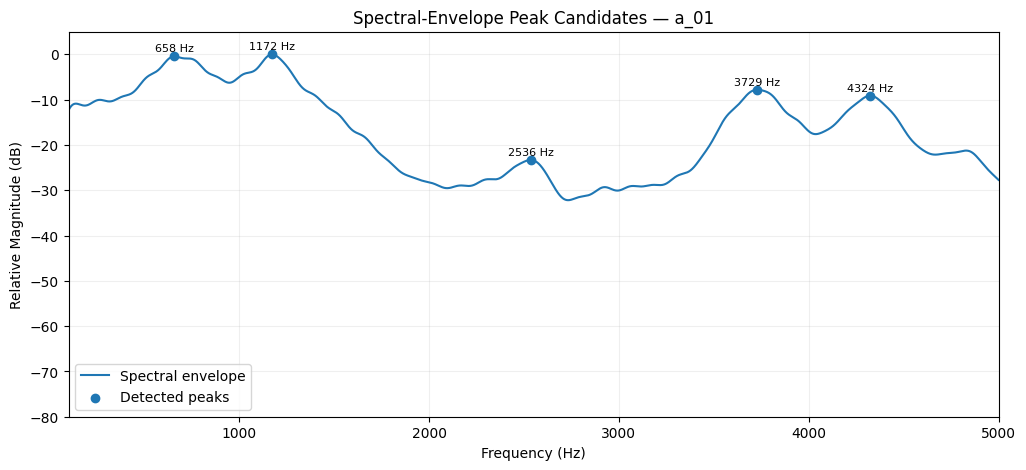

In [65]:
plt.figure(
  figsize=(12, 5)
)


plt.plot(
  analysis_freqs,
  analysis_envelope,
  label="Spectral envelope",
)


plt.scatter(
  peak_freqs,
  peak_db,
  zorder=3,
  label="Detected peaks",
)


for freq, db in zip(
  peak_freqs,
  peak_db,
):
  plt.text(
    freq,
    db + 1,
    f"{freq:.0f} Hz",
    ha="center",
    fontsize=8,
  )


plt.xlabel(
  "Frequency (Hz)"
)

plt.ylabel(
  "Relative Magnitude (dB)"
)

plt.title(
  "Spectral-Envelope Peak Candidates — a_01"
)

plt.xlim(
  100,
  5000,
)

plt.ylim(
  -80,
  5,
)

plt.legend()

plt.grid(
  alpha=0.2
)


plt.show()

In [66]:
peak_rows = []


for vowel in vowels:
  filename = (
    f"{vowel}_01.wav"
  )


  audio_path = (
    wav_dir / filename
  )


  wave_temp, sr_temp = sf.read(
    audio_path
  )


  freqs_temp, mag_db_temp = compute_spectrum(
    wave_temp,
    sr_temp,
  )


  envelope_temp = compute_spectral_envelope(
    freqs_temp,
    mag_db_temp,
    smoothing_sigma_hz=50,
  )


  mask = (
    (freqs_temp >= 100)
    & (freqs_temp <= 5000)
  )


  freqs_roi = freqs_temp[
    mask
  ]

  envelope_roi = envelope_temp[
    mask
  ]


  peak_indices, properties = find_peaks(
    envelope_roi,
    prominence=3,
  )


  peak_freqs_temp = freqs_roi[
    peak_indices
  ]


  peak_rows.append({
    "vowel": vowel,
    "peak_freqs_hz": np.round(
      peak_freqs_temp,
      1,
    ),
  })


peak_df = pd.DataFrame(
  peak_rows
)


display(
  peak_df
)

,vowel,peak_freqs_hz
0,a,"[657.5, 1172.0, 2535.5, 3729.0, 4324.0]"
1,e,"[518.5, 1752.0, 2415.0, 3318.5, 4446.5]"
2,i,"[365.0, 2199.5, 2760.0, 3366.0, 4399.5]"
3,o,"[422.0, 2287.5, 4066.0]"
4,u,"[395.5, 800.0, 2327.5, 3219.0, 4177.0]"


## 11. LPC Spectral Envelope

Gaussian smoothing is useful for visualization, but it does not explicitly model vocal-tract resonances.

Linear Predictive Coding (LPC) models a speech sample as approximately predictable from previous samples.

The resulting prediction model can be interpreted as an all-pole filter.

The resonances of this filter provide an approximation of vocal-tract resonance structure.

LPC is still a model rather than a direct physical measurement of the vocal tract.

In [67]:
def compute_lpc_envelope(
  wave,
  sr,
  center_duration=2.0,
  target_sr=10000,
  order=16,
  n_freqs=4096,
):
  center_sample = (
    len(wave) // 2
  )


  half_length = int(
    center_duration
    * sr
    / 2
  )


  start = max(
    0,
    center_sample - half_length,
  )

  end = min(
    len(wave),
    center_sample + half_length,
  )


  stable_wave = wave[
    start:end
  ]


  stable_wave = (
    stable_wave
    - np.mean(stable_wave)
  )


  if sr != target_sr:
    gcd = np.gcd(
      sr,
      target_sr,
    )


    up = (
      target_sr // gcd
    )

    down = (
      sr // gcd
    )


    stable_wave = resample_poly(
      stable_wave,
      up,
      down,
    )


    analysis_sr = (
      target_sr
    )

  else:
    analysis_sr = (
      sr
    )


  window = np.hanning(
    len(stable_wave)
  )


  windowed_wave = (
    stable_wave
    * window
  )


  lpc_coeffs = librosa.lpc(
    windowed_wave,
    order=order,
  )


  freqs_lpc, response = freqz(
    b=[1.0],
    a=lpc_coeffs,
    worN=n_freqs,
    fs=analysis_sr,
  )


  envelope_lpc_db = (
    20
    * np.log10(
      np.abs(response)
      + 1e-12
    )
  )


  envelope_lpc_db = (
    envelope_lpc_db
    - np.max(
      envelope_lpc_db
    )
  )


  return (
    freqs_lpc,
    envelope_lpc_db,
    lpc_coeffs,
  )

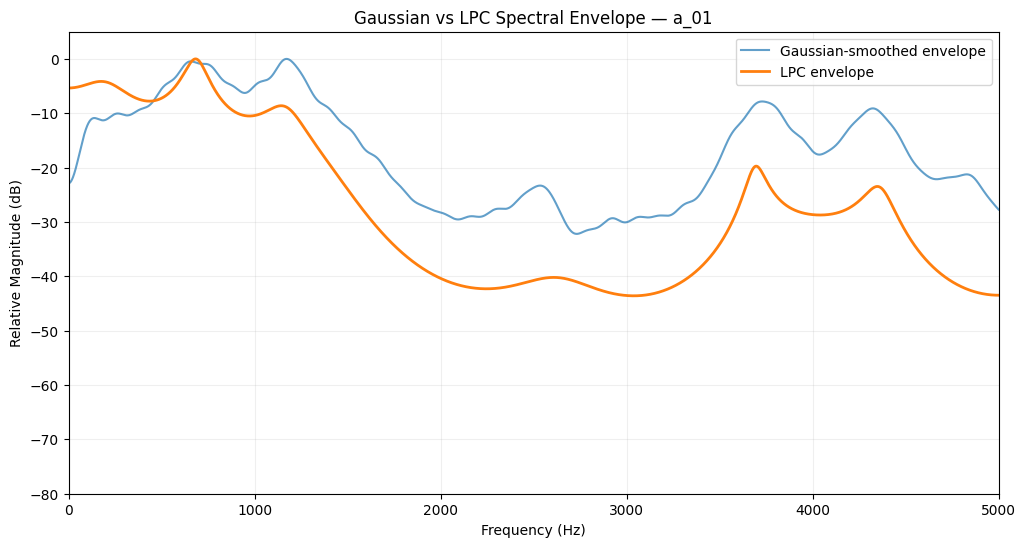

In [68]:
audio_path = (
  wav_dir / "a_01.wav"
)

wave, sr = sf.read(
  audio_path
)


freqs_raw, mag_db = compute_spectrum(
  wave,
  sr,
)


gaussian_envelope = compute_spectral_envelope(
  freqs_raw,
  mag_db,
  smoothing_sigma_hz=50,
)


(
  freqs_lpc,
  lpc_envelope,
  lpc_coeffs,
) = compute_lpc_envelope(
  wave,
  sr,
  order=16,
)


raw_mask = (
  freqs_raw <= 5000
)


plt.figure(
  figsize=(12, 6)
)


plt.plot(
  freqs_raw[raw_mask],
  gaussian_envelope[raw_mask],
  label="Gaussian-smoothed envelope",
  alpha=0.7,
)


plt.plot(
  freqs_lpc,
  lpc_envelope,
  label="LPC envelope",
  linewidth=2,
)


plt.xlabel(
  "Frequency (Hz)"
)

plt.ylabel(
  "Relative Magnitude (dB)"
)

plt.title(
  "Gaussian vs LPC Spectral Envelope — a_01"
)

plt.xlim(
  0,
  5000,
)

plt.ylim(
  -80,
  5,
)

plt.legend()

plt.grid(
  alpha=0.2
)


plt.show()

### 11.1 LPC Order Stability

The LPC spectral envelope depends on model order.

Too low an order may miss resonances.

Too high an order may model small spectral details as additional resonances.

Several orders are therefore compared.

Resonances that remain at approximately the same frequency across reasonable orders are more robust candidates.

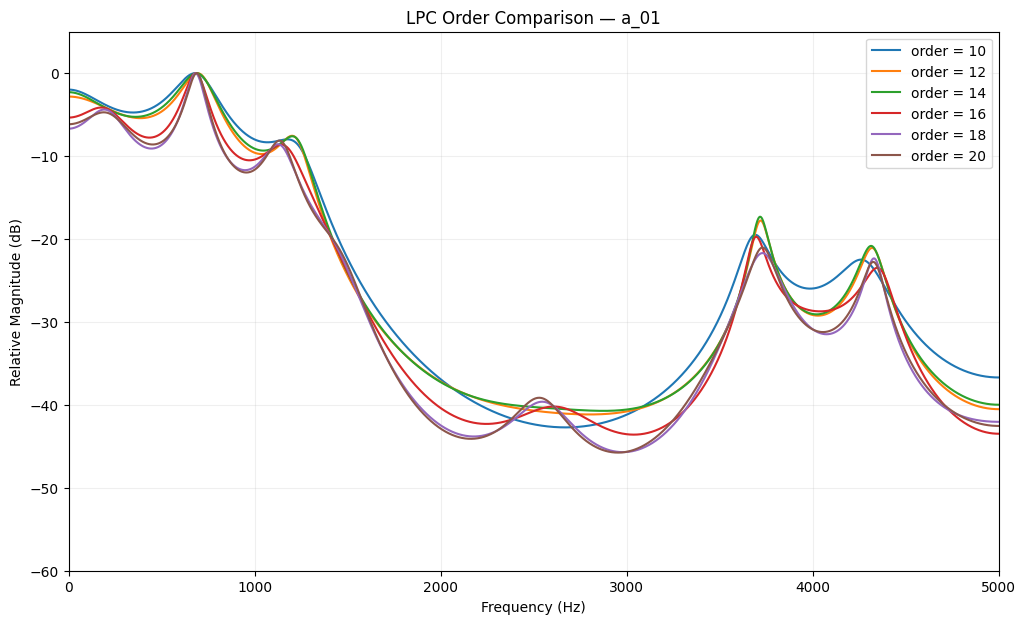

In [69]:
lpc_orders = [
  10,
  12,
  14,
  16,
  18,
  20,
]


plt.figure(
  figsize=(12, 7)
)


for order in lpc_orders:
  (
    freqs_lpc,
    lpc_envelope,
    lpc_coeffs,
  ) = compute_lpc_envelope(
    wave,
    sr,
    order=order,
  )


  plt.plot(
    freqs_lpc,
    lpc_envelope,
    label=f"order = {order}",
  )


plt.xlabel(
  "Frequency (Hz)"
)

plt.ylabel(
  "Relative Magnitude (dB)"
)

plt.title(
  "LPC Order Comparison — a_01"
)

plt.xlim(
  0,
  5000,
)

plt.ylim(
  -60,
  5,
)

plt.legend()

plt.grid(
  alpha=0.2
)


plt.show()

## 12. LPC Poles and Formant Candidates

The LPC spectral envelope is the frequency response of an all-pole model.

Instead of detecting peaks only from the plotted curve, the roots of the LPC prediction polynomial can be analyzed directly.

Complex-conjugate pole pairs correspond to resonant modes.

For each pole:

- pole angle determines resonance frequency,
- pole radius determines damping,
- damping can be expressed as bandwidth.

This produces resonance candidates represented by both frequency and bandwidth.

These candidates are not automatically guaranteed to be physical formants.

In [70]:
def compute_lpc_formant_candidates(
  frame,
  sr,
  order=12,
  pre_emphasis=0.97,
  min_freq=90,
  max_freq=5000,
  max_bandwidth=500,
):
  frame = (
    frame
    - np.mean(frame)
  )


  emphasized = lfilter(
    [1.0, -pre_emphasis],
    [1.0],
    frame,
  )


  window = np.hamming(
    len(emphasized)
  )


  windowed = (
    emphasized
    * window
  )


  lpc_coeffs = librosa.lpc(
    windowed,
    order=order,
  )


  roots = np.roots(
    lpc_coeffs
  )


  roots = roots[
    np.imag(roots) >= 0
  ]


  radii = np.abs(
    roots
  )


  angles = np.angle(
    roots
  )


  formant_freqs = (
    angles
    * sr
    / (2 * np.pi)
  )


  bandwidths = (
    -sr
    / np.pi
    * np.log(
      radii
    )
  )


  valid = (
    (formant_freqs >= min_freq)
    & (formant_freqs <= max_freq)
    & (radii < 1.0)
    & (bandwidths > 0)
    & (bandwidths <= max_bandwidth)
  )


  formant_freqs = (
    formant_freqs[
      valid
    ]
  )


  bandwidths = (
    bandwidths[
      valid
    ]
  )


  order_idx = np.argsort(
    formant_freqs
  )


  formant_freqs = (
    formant_freqs[
      order_idx
    ]
  )


  bandwidths = (
    bandwidths[
      order_idx
    ]
  )


  return (
    formant_freqs,
    bandwidths,
  )

In [71]:
audio_path = (
  wav_dir / "a_01.wav"
)


wave, sr = sf.read(
  audio_path
)


target_sr = 10000


center_sample = (
  len(wave) // 2
)


frame_duration = (
  0.03
)


half_frame = int(
  frame_duration
  * sr
  / 2
)


frame = wave[
  center_sample - half_frame:
  center_sample + half_frame
]


gcd = np.gcd(
  sr,
  target_sr,
)


up = (
  target_sr // gcd
)

down = (
  sr // gcd
)


frame_resampled = resample_poly(
  frame,
  up,
  down,
)


(
  formant_freqs,
  formant_bandwidths,
) = compute_lpc_formant_candidates(
  frame_resampled,
  target_sr,
  order=12,
)


formant_candidate_df = pd.DataFrame({
  "frequency_hz": formant_freqs,
  "bandwidth_hz": formant_bandwidths,
})


formant_candidate_df = (
  formant_candidate_df
  .round(1)
)


display(
  formant_candidate_df
)

,frequency_hz,bandwidth_hz
0,692.3,135.3
1,1209.3,122.5
2,3698.4,135.7
3,4369.5,139.9


## 13. Temporal LPC Resonance Stability

A single 30 ms frame provides only a snapshot of the vocal-tract model.

A sustained vowel should produce resonance candidates that remain in similar frequency regions across many neighboring frames.

The central 2 seconds of each recording are therefore divided into short overlapping frames.

For each frame:

1. LPC coefficients are estimated,
2. LPC polynomial roots are calculated,
3. pole frequencies and bandwidths are extracted,
4. implausibly broad resonances are removed.

The resulting frequency-bandwidth candidates are observed across time.

Stable horizontal clusters of candidates are stronger formant candidates than isolated or rapidly moving poles.